# Covariance Features - DCC GARCH (Daily, 8 Coins)
DCC-GARCH on 8 cryptocurrencies, daily closing prices from 1 Apr 2022 to 31st Dec 2025.

**Stages:**
1. Log returns & stationarity checks
2. Univariate GARCH fitting
3. DCC estimation
4. Covariance matrix reconstruction
5. Evaluation (log-likelihood, portfolio variance, covariance RMSE)

## 0. Imports & Data Loading

In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model
from joblib import Parallel, delayed
from numba import njit
import warnings

warnings.filterwarnings("ignore")

In [2]:
filepath = 'klines csv data/prices_cleaned'

all_coins = sorted(os.listdir(filepath))

# Preview first coin
glimpse = pd.read_csv(filepath + "/" + all_coins[0])
print(all_coins[0])
print(glimpse.head())
print(f"shape: {glimpse.shape}\n")

# Filter out non-csv files
all_coins = [coin for coin in all_coins if not coin.endswith(".keras")]

# Merge all data into single dataframe
combined = pd.DataFrame({'time': pd.date_range(start='2022-04-01', periods=len(glimpse), freq='D')})
for coin in all_coins:
    combined[coin] = pd.read_csv(filepath + "/" + coin).sort_values(by='time').close

combined = combined.set_index('time')
print(f"Combined shape: {combined.shape}")
print(f"Coins: {list(combined.columns)}")
combined.head()

ADAUSDT
   Unnamed: 0  close    time
0           0  1.165       0
1           1  1.155   86400
2           2  1.186  172800
3           3  1.212  259200
4           4  1.171  345600
shape: (1371, 3)

Combined shape: (1371, 8)
Coins: ['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']


,ADAUSDT,BCHUSDT,BNBUSDT,BTCUSDT,ETHUSDT,SOLUSDT,TRXUSDT,XRPUSDT
time,,,,,,,,
2022-04-01,1.165,377.2,447.7,46283.49,3455.21,134.52,0.07494,0.8277
2022-04-02,1.155,372.5,437.2,45811.00,3443.77,132.49,0.07322,0.8240
2022-04-03,1.186,378.6,450.4,46407.35,3521.91,136.90,0.07312,0.8432
2022-04-04,1.212,376.2,447.6,46580.51,3519.50,132.14,0.07070,0.8260
2022-04-05,1.171,365.4,444.7,45497.55,3406.99,126.87,0.06928,0.8164


## 1. Train/Test Split

In [3]:
def train_test_split(combined, train_size=0.8, test_size=0.2):
    """
    args: coin price dataframe & training size
    returns: train & test dataframes
    """
    combined = combined.sort_values(by='time')

    split = math.ceil(combined.shape[0] * train_size)
    spli = math.ceil(combined.shape[0] * (train_size + test_size))
    train = combined.iloc[:split]
    test = combined.iloc[split:spli]
    final_test = combined.iloc[spli:]

    print(f"df with {combined.shape[0]} rows split at {split}")
    print(f"train shape: {train.shape}")
    print(f"test shape: {test.shape}")

    return train, test, final_test

In [4]:
train, test, final_test = train_test_split(combined)

df with 1371 rows split at 1097
train shape: (1097, 8)
test shape: (274, 8)


## 2. DCC GARCH
### Stage 1: Log Returns & Stationarity Checks

In [5]:
# Compute log returns
log_returns = np.log(train / train.shift(1)).dropna()

print(f"Prices shape:       {train.shape}")
print(f"Log returns shape:  {log_returns.shape}")
print(f"Date range:         {log_returns.index[0]} to {log_returns.index[-1]}")

Prices shape:       (1097, 8)
Log returns shape:  (1096, 8)
Date range:         2022-04-02 00:00:00 to 2025-04-01 00:00:00


In [6]:
log_returns.head()

,ADAUSDT,BCHUSDT,BNBUSDT,BTCUSDT,ETHUSDT,SOLUSDT,TRXUSDT,XRPUSDT
time,,,,,,,,
2022-04-02,-0.008621,-0.012539,-0.023733,-0.010261,-0.003316,-0.015206,-0.023219,-0.004480
2022-04-03,0.026486,0.016243,0.029745,0.012934,0.022437,0.032744,-0.001367,0.023034
2022-04-04,0.021686,-0.006359,-0.006236,0.003724,-0.000685,-0.035389,-0.033656,-0.020609
2022-04-05,-0.034414,-0.029128,-0.006500,-0.023524,-0.032490,-0.040699,-0.020289,-0.011690
2022-04-06,-0.107165,-0.098874,-0.056907,-0.052502,-0.072568,-0.116218,-0.093753,-0.072244


In [7]:
# ADF and KPSS tests for all coins
stationarity_results = []

for coin in all_coins:
    print(f"running tests for {coin}...")

    series = log_returns[coin].dropna()

    # ADF: H0 = non-stationary. Reject (p < 0.05) -> stationary
    adf_stat, adf_pval, _, _, _, _ = adfuller(series, autolag="AIC")

    # KPSS: H0 = stationary. Fail to reject (p > 0.05) -> stationary
    kpss_stat, kpss_pval, _, _ = kpss(series, regression="c", nlags="auto")

    stationarity_results.append({
        "coin": coin,
        "adf_pvalue": adf_pval,
        "kpss_pvalue": kpss_pval,
        "stationary_adf": adf_pval < 0.05,
        "stationary_kpss": kpss_pval > 0.05,
    })

stationarity_df = pd.DataFrame(stationarity_results)
print(f"Stationary by ADF:  {stationarity_df['stationary_adf'].sum()}/{len(all_coins)}")
print(f"Stationary by KPSS: {stationarity_df['stationary_kpss'].sum()}/{len(all_coins)}")

running tests for ADAUSDT...
running tests for BCHUSDT...
running tests for BNBUSDT...
running tests for BTCUSDT...
running tests for ETHUSDT...
running tests for SOLUSDT...
running tests for TRXUSDT...
running tests for XRPUSDT...
Stationary by ADF:  8/8
Stationary by KPSS: 7/8


note: the ADT Test values are small and negligible which is why the graph appears empty


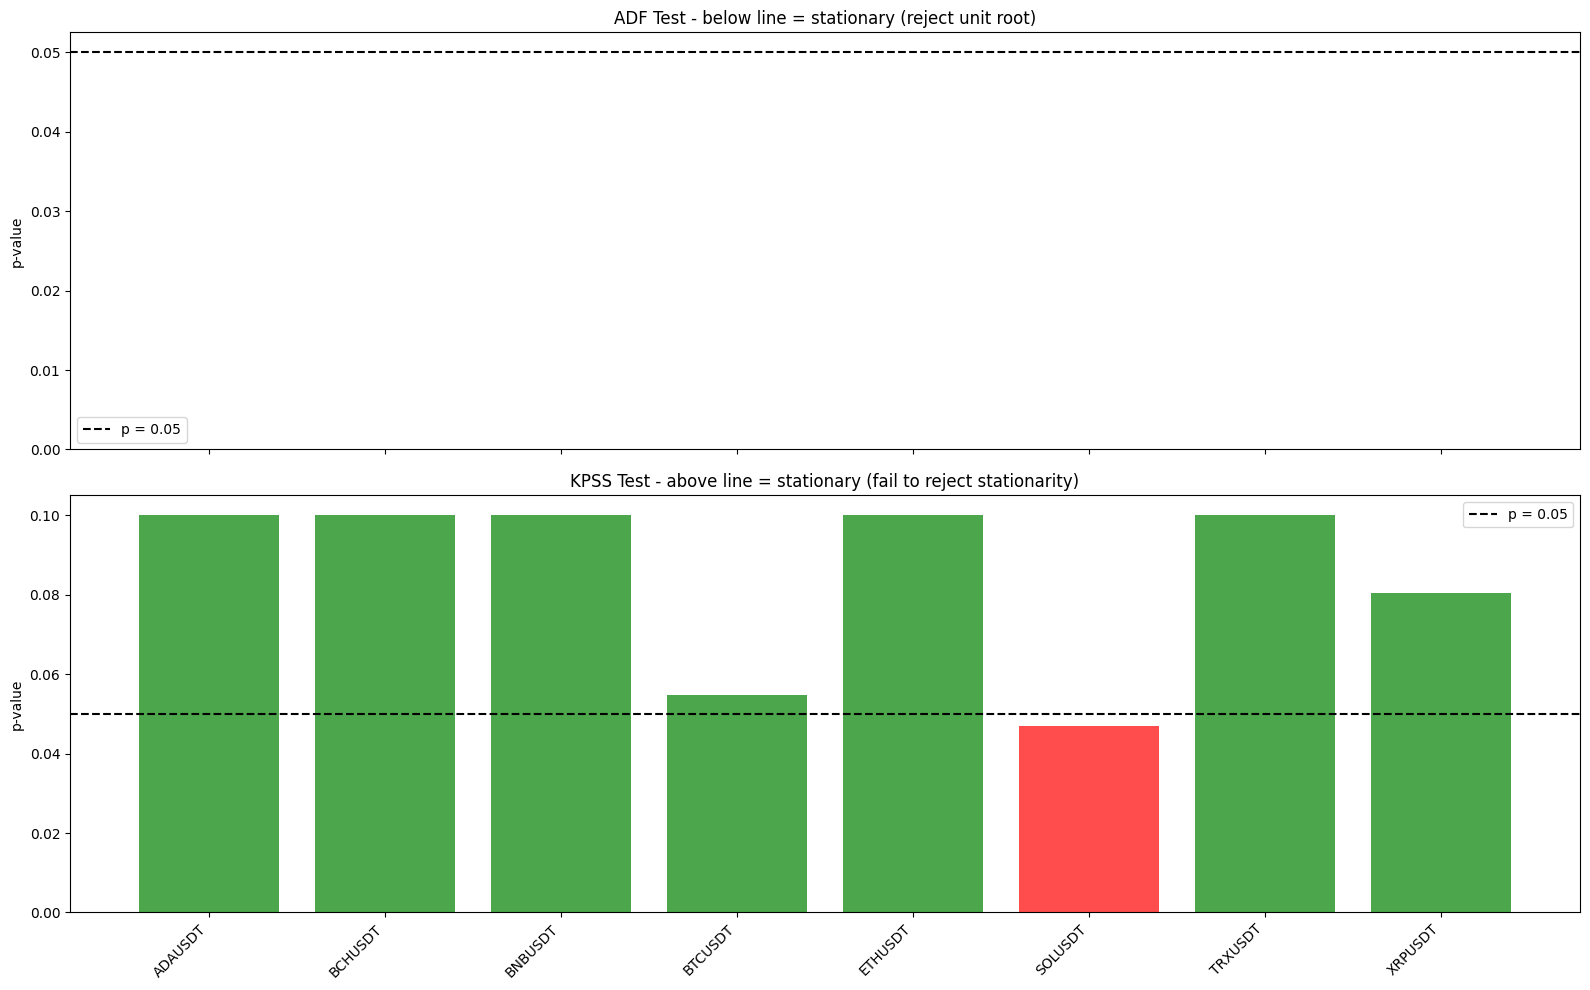

In [8]:
# Plot ADF and KPSS p-values
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

colors_adf = ["green" if p < 0.05 else "red" for p in stationarity_df["adf_pvalue"]]
axes[0].bar(stationarity_df["coin"], stationarity_df["adf_pvalue"], color=colors_adf, alpha=0.7)
axes[0].axhline(y=0.05, color="black", linestyle="--", linewidth=1.5, label="p = 0.05")
axes[0].set_ylabel("p-value")
axes[0].set_title("ADF Test - below line = stationary (reject unit root)")
axes[0].legend()

colors_kpss = ["green" if p > 0.05 else "red" for p in stationarity_df["kpss_pvalue"]]
axes[1].bar(stationarity_df["coin"], stationarity_df["kpss_pvalue"], color=colors_kpss, alpha=0.7)
axes[1].axhline(y=0.05, color="black", linestyle="--", linewidth=1.5, label="p = 0.05")
axes[1].set_ylabel("p-value")
axes[1].set_title("KPSS Test - above line = stationary (fail to reject stationarity)")
axes[1].legend()

print("note: the ADT Test values are small and negligible which is why the graph appears empty")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
# Ljung-Box test on squared returns to confirm ARCH effects
arch_results = []

for coin in all_coins:
    print(f"running for {coin}...")

    squared = log_returns[coin] ** 2
    lb = acorr_ljungbox(squared.dropna(), lags=[5], return_df=True)
    pval = lb["lb_pvalue"].values[0]
    arch_results.append({"coin": coin, "lb_pvalue": pval, "arch_effects": pval < 0.05})

arch_df = pd.DataFrame(arch_results)
print(f"Coins with ARCH effects: {arch_df['arch_effects'].sum()}/{len(all_coins)}")
print("(ARCH effects = GARCH modeling is justified)")

running for ADAUSDT...
running for BCHUSDT...
running for BNBUSDT...
running for BTCUSDT...
running for ETHUSDT...
running for SOLUSDT...
running for TRXUSDT...
running for XRPUSDT...
Coins with ARCH effects: 8/8
(ARCH effects = GARCH modeling is justified)


### Stage 2: GARCH Fitting
**Student-t** chosen over normal because crypto returns have fat tails — extreme returns are common, not rare.

In [10]:
def fit_single_garch(returns, coin_name, vol_model="GARCH", p=1, q=1, dist="t"):
    """Fit univariate GARCH to one coin. Returns are scaled by 100 for numerical stability."""
    scaled = returns * 100
    am = arch_model(scaled, vol=vol_model, p=p, q=q, dist=dist, mean="Constant")
    result = am.fit(disp="off", show_warning=False)

    std_resid = (result.resid / result.conditional_volatility).values
    cond_vol = result.conditional_volatility.values

    return {
        "coin": coin_name,
        "model": result,
        "std_resid": std_resid,
        "cond_vol": cond_vol,
        "aic": result.aic,
        "bic": result.bic,
    }

In [11]:
# Fit GARCH(1,1) with Student-t errors to all coins in parallel
garch_results = Parallel(n_jobs=-1, verbose=1)(
    delayed(fit_single_garch)(log_returns[coin].dropna(), coin)
    for coin in all_coins
)

# Sort to match original column order
garch_results = sorted(garch_results, key=lambda x: all_coins.index(x["coin"]))

# Print AIC/BIC summary
for r in garch_results:
    print(f"  {r['coin']:>10s}   AIC={r['aic']:.1f}   BIC={r['bic']:.1f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


     ADAUSDT   AIC=6049.7   BIC=6074.6
     BCHUSDT   AIC=6039.5   BIC=6064.5
     BNBUSDT   AIC=5242.2   BIC=5267.2
     BTCUSDT   AIC=5104.5   BIC=5129.5
     ETHUSDT   AIC=5617.4   BIC=5642.4
     SOLUSDT   AIC=6541.4   BIC=6566.4
     TRXUSDT   AIC=4816.2   BIC=4841.2
     XRPUSDT   AIC=5767.3   BIC=5792.3


[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    8.1s remaining:   13.6s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    8.2s finished


In [12]:
# Build the standardized residuals matrix
min_len = min(len(r["std_resid"]) for r in garch_results)

std_residuals = np.column_stack([r["std_resid"][-min_len:] for r in garch_results])

print(f"Standardized residuals matrix shape: {std_residuals.shape}")
print(f"  Rows = {std_residuals.shape[0]} time steps")
print(f"  Cols = {std_residuals.shape[1]} coins")

Standardized residuals matrix shape: (1096, 8)
  Rows = 1096 time steps
  Cols = 8 coins


#### Checking GARCH fittings

In [13]:
# Basic stats - should be mean ~ 0, std ~ 1
print("Means:", np.round(std_residuals.mean(axis=0), 4))
print("Stds:", np.round(std_residuals.std(axis=0), 4))

# Check for extreme outliers
print("Min:", np.round(std_residuals.min(axis=0), 2))
print("Max:", np.round(std_residuals.max(axis=0), 2))

# Flag problematic coins
stds = std_residuals.std(axis=0)
for i, (coin, sd) in enumerate(zip(all_coins, stds)):
    if sd < 0.8 or sd > 1.2:
        print(f"  [{i}] {coin}: std = {sd:.4f}  <- problematic")

Means: [ 0.0158  0.0135 -0.0099  0.0105 -0.0134  0.0138 -0.0073  0.0315]
Stds: [1.0353 0.9739 0.9373 0.8625 0.9393 0.9966 1.0804 1.0642]
Min: [-4.64 -4.09 -6.11 -4.17 -4.34 -5.83 -7.08 -3.91]
Max: [12.02 10.5   4.94  3.82  5.34  4.85 17.62 18.76]


In [14]:
# Filter out bad coins if any
stds = std_residuals.std(axis=0)
good_mask = (stds > 0.8) & (stds < 1.2)
good_coins = [c for c, g in zip(all_coins, good_mask) if g]
bad_coins = [c for c, g in zip(all_coins, good_mask) if not g]
good_residuals = np.ascontiguousarray(std_residuals[:, good_mask])

good_garch = [r for r, g in zip(garch_results, good_mask) if g]

print(f"Keeping {len(good_coins)}/{len(all_coins)} coins")
print(f"Good coins: {good_coins}")
if bad_coins:
    print(f"Removed: {bad_coins}")
else:
    print("All coins have good GARCH fits!")

Keeping 8/8 coins
Good coins: ['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']
All coins have good GARCH fits!


### Stage 3: DCC Estimation

In [15]:
@njit
def dcc_recursion(std_resid, a, b):
    T, N = std_resid.shape

    Q_bar = np.zeros((N, N))
    for t in range(T):
        z = std_resid[t, :].reshape(-1, 1)
        Q_bar += z @ z.T
    Q_bar /= T

    R_all = np.zeros((T, N, N))
    Q_all = np.zeros((T, N, N))
    Q_prev = Q_bar.copy()

    for t in range(T):
        z = std_resid[t, :].reshape(-1, 1)
        outer = z @ z.T

        Q_t = (1.0 - a - b) * Q_bar + a * outer + b * Q_prev

        diag_inv = np.zeros(N)
        for i in range(N):
            diag_inv[i] = 1.0 / np.sqrt(Q_t[i, i])

        R_t = np.zeros((N, N))
        for i in range(N):
            for j in range(N):
                R_t[i, j] = diag_inv[i] * Q_t[i, j] * diag_inv[j]

        R_all[t] = R_t
        Q_all[t] = Q_t
        Q_prev = Q_t

    return R_all, Q_all

In [16]:
def dcc_neg_log_likelihood(params, std_resid):
    """Negative log-likelihood for DCC parameters [a, b]."""
    a, b = params

    if a <= 0 or b <= 0 or a + b >= 1:
        return 1e10

    R_all, Q_all = dcc_recursion(std_resid, a, b)
    T, N = std_resid.shape

    ll = 0.0
    for t in range(T):
        R_t = R_all[t]
        z_t = std_resid[t, :]
        try:
            sign, logdet = np.linalg.slogdet(R_t)
            if sign <= 0:
                return 1e10
            R_inv = np.linalg.inv(R_t)
            ll += -0.5 * (logdet + z_t @ R_inv @ z_t - z_t @ z_t)
        except np.linalg.LinAlgError:
            return 1e10

    return -ll

In [17]:
# Estimate DCC parameters via MLE with multiple initial guesses
initial_guesses = [
    np.array([0.02, 0.95]),
    np.array([0.05, 0.90]),
    np.array([0.01, 0.97]),
    np.array([0.10, 0.85]),
]

best_result = None
best_nll = np.inf

# Use good_residuals if bad coins were removed, otherwise std_residuals
resid_to_use = good_residuals if bad_coins else std_residuals
coins_to_use = good_coins if bad_coins else all_coins
garch_to_use = good_garch if bad_coins else garch_results

for x0 in initial_guesses:
    print(f"running {x0}...")
    res = minimize(
        dcc_neg_log_likelihood,
        x0,
        args=(resid_to_use,),
        method="L-BFGS-B",
        bounds=[(0.001, 0.5), (0.3, 0.999)],
        options={"maxiter": 1000, "ftol": 1e-12},
    )
    if res.fun < best_nll:
        best_nll = res.fun
        best_result = res

a_hat, b_hat = best_result.x
print(f"\nBest: a = {a_hat:.6f}, b = {b_hat:.6f}, a+b = {a_hat+b_hat:.6f}")

running [0.02 0.95]...
running [0.05 0.9 ]...
running [0.01 0.97]...
running [0.1  0.85]...

Best: a = 0.027076, b = 0.972918, a+b = 0.999995


### Stage 4: Covariance Matrix Reconstruction

In [18]:
# Final time-varying correlation matrices
R_all, Q_all = dcc_recursion(resid_to_use, a_hat, b_hat)
print(f"Correlation matrices shape: {R_all.shape}")
print(f"  = {R_all.shape[0]} time steps x {R_all.shape[1]}x{R_all.shape[2]} correlation matrix")

Correlation matrices shape: (1096, 8, 8)
  = 1096 time steps x 8x8 correlation matrix


In [19]:
# Reconstruct full covariance matrices: H_t = D_t @ R_t @ D_t
cond_vols = np.column_stack([r["cond_vol"][-min_len:] / 100.0 for r in garch_to_use])

T, N = resid_to_use.shape
H_all = np.zeros((T, N, N))

for t in range(T):
    D_t = np.diag(cond_vols[t, :])
    H_all[t] = D_t @ R_all[t] @ D_t

print(f"Covariance matrices shape: {H_all.shape}")

Covariance matrices shape: (1096, 8, 8)


### Stage 5: Evaluation
- Out-of-sample covariance forecasting on test set
- Covariance forecast RMSE across multiple horizons
- Predicted vs realised pairwise covariance plots

In [20]:
def compute_test_covariance(test_df, coin_list, garch_results_list, Q_all, std_residuals):
    """
    Compute out-of-sample DCC covariance matrices on the test set.
    Returns test log returns, correlation matrices, and covariance matrices.
    """
    # --- 1. Compute log returns on test set ---
    test_log_returns = np.log(test_df / test_df.shift(1)).dropna()

    print(f"Test log returns shape: {test_log_returns.shape}")
    print(f"Test period: {test_log_returns.index[0]} to {test_log_returns.index[-1]}")

    # --- 2. Standardize test returns using trained GARCH parameters ---
    test_std_residuals = np.zeros((len(test_log_returns), len(coin_list)))
    test_cond_vols = np.zeros((len(test_log_returns), len(coin_list)))

    for i, (coin, gr) in enumerate(zip(coin_list, garch_results_list)):
        trained_model = gr["model"]
        params = trained_model.params

        full_series = pd.concat([
            pd.Series(gr["model"].resid.values[-50:]),  # Last 50 days for warm-up
            test_log_returns[coin] * 100,
        ])

        am = arch_model(full_series, vol=trained_model.model.volatility.__class__.__name__,
                        p=1, q=1, dist="t", mean="Constant")

        filtered = am.fit(
            disp="off",
            show_warning=False,
            starting_values=params.values,
            options={"maxiter": 0},
        )

        warmup = 50
        test_resid = filtered.resid.values[warmup:]
        test_vol = filtered.conditional_volatility.values[warmup:]

        T_test = len(test_log_returns)
        test_resid = test_resid[:T_test]
        test_vol = test_vol[:T_test]

        test_std_residuals[:, i] = test_resid / test_vol
        test_cond_vols[:, i] = test_vol / 100.0

    print(f"Test std residuals shape: {test_std_residuals.shape}")
    print(f"Means: {np.round(test_std_residuals.mean(axis=0)[:5], 4)}")
    print(f"Stds:  {np.round(test_std_residuals.std(axis=0)[:5], 4)}")

    # --- 3. Run DCC recursion on test data ---
    Q_prev_from_training = Q_all[-1]

    T_train = std_residuals.shape[0]
    N = len(coin_list)

    Q_bar = np.zeros((N, N))
    for t in range(T_train):
        z = std_residuals[t, :].reshape(-1, 1)
        Q_bar += z @ z.T
    Q_bar /= T_train

    T_test = test_std_residuals.shape[0]
    test_std_resid_contig = np.ascontiguousarray(test_std_residuals)

    test_R_all = np.zeros((T_test, N, N))
    Q_prev = Q_prev_from_training.copy()

    for t in range(T_test):
        z = test_std_resid_contig[t, :].reshape(-1, 1)
        outer = z @ z.T

        Q_t = (1.0 - a_hat - b_hat) * Q_bar + a_hat * outer + b_hat * Q_prev

        diag_inv = 1.0 / np.sqrt(np.diag(Q_t))
        R_t = Q_t * np.outer(diag_inv, diag_inv)

        test_R_all[t] = R_t
        Q_prev = Q_t

    print(f"Test correlation matrices shape: {test_R_all.shape}")

    # --- 4. Reconstruct test covariance matrices ---
    test_H_all = np.zeros((T_test, N, N))

    for t in range(T_test):
        D_t = np.diag(test_cond_vols[t, :])
        test_H_all[t] = D_t @ test_R_all[t] @ D_t

    print(f"Test covariance matrices shape: {test_H_all.shape}")

    return test_log_returns, test_R_all, test_H_all

In [21]:
# Compute out-of-sample covariance matrices
test_filtered = test[coins_to_use]
test_log_returns, test_R_all, test_H_all = compute_test_covariance(
    test_filtered, coins_to_use, garch_to_use, Q_all, resid_to_use
)

Test log returns shape: (273, 8)
Test period: 2025-04-03 00:00:00 to 2025-12-31 00:00:00
Test std residuals shape: (273, 8)
Means: [-0.0469  0.0897  0.0412 -0.0075  0.0341]
Stds:  [1.0526 0.8823 0.8462 0.7326 0.9631]
Test correlation matrices shape: (273, 8, 8)
Test covariance matrices shape: (273, 8, 8)


#### Covariance Forecast RMSE

In [22]:
def covariance_forecast_rmse(
    test_H_all: np.ndarray,
    test_returns: np.ndarray,
    interval_days: int,
    coin_names: list = None,
) -> dict:
    """
    Compute RMSE between DCC-predicted and realized covariance matrices
    at specified time intervals.
    """
    T, N, _ = test_H_all.shape

    if coin_names is None:
        coin_names = [f"coin_{i}" for i in range(N)]

    upper_i, upper_j = np.triu_indices(N, k=0)  # k=0 includes diagonal (variances)
    n_elements = len(upper_i)

    if interval_days == 1:
        per_interval_rmse = np.zeros(T)
        all_squared_errors = []

        for t in range(T):
            r_t = test_returns[t, :]

            realized_cov_proxy = np.outer(r_t, r_t)
            predicted_cov = test_H_all[t]

            pred_upper = predicted_cov[upper_i, upper_j]
            real_upper = realized_cov_proxy[upper_i, upper_j]

            sq_errors = (pred_upper - real_upper) ** 2
            all_squared_errors.append(sq_errors)
            per_interval_rmse[t] = np.sqrt(np.mean(sq_errors))

        all_squared_errors = np.concatenate(all_squared_errors)
        overall_rmse = np.sqrt(np.mean(all_squared_errors))

        summary_df = pd.DataFrame({
            "interval": range(1, T + 1),
            "start_day": range(T),
            "end_day": range(1, T + 1),
            "rmse": per_interval_rmse,
        })

        n_intervals = T

    else:
        n_intervals = T // interval_days
        per_interval_rmse = np.zeros(n_intervals)
        all_squared_errors = []

        for k in range(n_intervals):
            start = k * interval_days
            end = (k + 1) * interval_days

            predicted_cov = test_H_all[start:end].mean(axis=0)
            interval_returns = test_returns[start:end]

            if len(interval_returns) < 3:
                per_interval_rmse[k] = np.nan
                continue

            realized_cov = np.cov(interval_returns, rowvar=False)

            pred_upper = predicted_cov[upper_i, upper_j]
            real_upper = realized_cov[upper_i, upper_j]

            sq_errors = (pred_upper - real_upper) ** 2
            all_squared_errors.append(sq_errors)
            per_interval_rmse[k] = np.sqrt(np.mean(sq_errors))

        all_squared_errors = np.concatenate(all_squared_errors)
        overall_rmse = np.sqrt(np.mean(all_squared_errors))

        summary_df = pd.DataFrame({
            "interval": range(1, n_intervals + 1),
            "start_day": [k * interval_days for k in range(n_intervals)],
            "end_day": [(k + 1) * interval_days for k in range(n_intervals)],
            "rmse": per_interval_rmse,
        })

    valid_rmse = per_interval_rmse[~np.isnan(per_interval_rmse)]

    label = "1-day (outer product proxy)" if interval_days == 1 else f"{interval_days}-day (sample covariance)"
    print(f"Covariance Forecast RMSE - {label}")
    print(f"  Intervals:    {n_intervals}")
    print(f"  Elements:     {n_elements} (upper triangle + diagonal)")
    print(f"  Overall RMSE: {overall_rmse:.6f}")
    print(f"  Mean RMSE:    {np.nanmean(valid_rmse):.6f}")
    print(f"  Min RMSE:     {np.nanmin(valid_rmse):.6f}")
    print(f"  Max RMSE:     {np.nanmax(valid_rmse):.6f}")

    return {
        "overall_rmse": overall_rmse,
        "per_interval_rmse": per_interval_rmse,
        "interval_count": n_intervals,
        "interval_days": interval_days,
        "pair_count": n_elements,
        "summary_df": summary_df,
    }

In [23]:
# Compare across interval sizes
results = {}
for interval in [1, 5, 7, 10, 20, 30]:
    results[interval] = covariance_forecast_rmse(
        test_H_all=test_H_all,
        test_returns=test_log_returns[coins_to_use].values,
        interval_days=interval,
        coin_names=coins_to_use,
    )
    print()

Covariance Forecast RMSE - 1-day (outer product proxy)
  Intervals:    273
  Elements:     36 (upper triangle + diagonal)
  Overall RMSE: 0.002222
  Mean RMSE:    0.001383
  Min RMSE:     0.000358
  Max RMSE:     0.021354

Covariance Forecast RMSE - 5-day (sample covariance)
  Intervals:    54
  Elements:     36 (upper triangle + diagonal)
  Overall RMSE: 0.000999
  Mean RMSE:    0.000797
  Min RMSE:     0.000352
  Max RMSE:     0.004323

Covariance Forecast RMSE - 7-day (sample covariance)
  Intervals:    39
  Elements:     36 (upper triangle + diagonal)
  Overall RMSE: 0.000842
  Mean RMSE:    0.000707
  Min RMSE:     0.000257
  Max RMSE:     0.002621

Covariance Forecast RMSE - 10-day (sample covariance)
  Intervals:    27
  Elements:     36 (upper triangle + diagonal)
  Overall RMSE: 0.000653
  Mean RMSE:    0.000577
  Min RMSE:     0.000228
  Max RMSE:     0.001689

Covariance Forecast RMSE - 20-day (sample covariance)
  Intervals:    13
  Elements:     36 (upper triangle + diagon

In [24]:
# Export daily RMSE
# daily_rmse = results[1]['summary_df']
# daily_rmse.insert(loc=0, column='time', value=test_filtered.index[1:len(daily_rmse)+1])
# daily_rmse = daily_rmse.drop(['interval', 'start_day', 'end_day'], axis=1)
# daily_rmse.head()

##### Predicted vs Realised Pairwise Covariance (first 6 pairs)

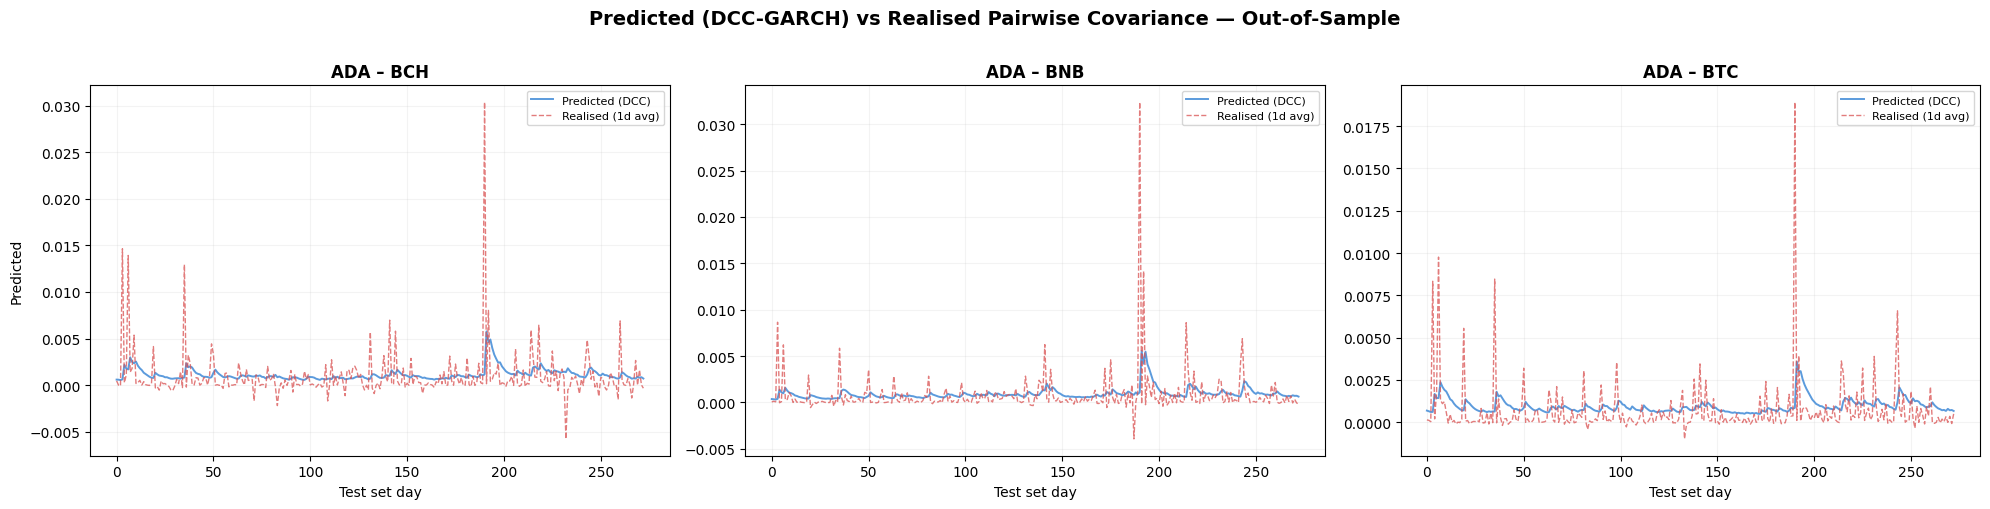

In [25]:
import itertools

pair_indices = list(itertools.combinations(range(len(coins_to_use)), 2))[:3]

# Test returns for realised covariance proxy
test_returns_array = test_log_returns[coins_to_use].values  # shape (T, N)

# Smoothing window for realised covariance
SMOOTH_WINDOW = 1

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True)
axes = axes.flatten()

for idx, (i, j) in enumerate(pair_indices):
    ax = axes[idx]
    coin_i = coins_to_use[i].replace("USDT", "")
    coin_j = coins_to_use[j].replace("USDT", "")

    # Predicted: DCC covariance entry (i, j) at each time step
    predicted = test_H_all[:, i, j]

    # Realised: outer product proxy r_i * r_j
    realized_raw = test_returns_array[:, i] * test_returns_array[:, j]

    # Smooth realised with rolling mean
    realized_smooth = pd.Series(realized_raw).rolling(
        window=SMOOTH_WINDOW, center=True, min_periods=1
    ).mean().values

    # Plot
    ax.plot(predicted, color="#4a90d9", linewidth=1.4, label="Predicted (DCC)", alpha=0.9)
    ax.plot(realized_smooth, color="#d95050", linewidth=1.0, linestyle="--",
            label=f"Realised ({SMOOTH_WINDOW}d avg)", alpha=0.75)
    ax.set_title(f"{coin_i} – {coin_j}", fontsize=12, fontweight="bold")
    # ax.set_ylabel("Covariance")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.15)

# axes[-4].set_xlabel("Test set day")
axes[-3].set_xlabel("Test set day")
axes[-2].set_xlabel("Test set day")
axes[-1].set_xlabel("Test set day")
axes[0].set_ylabel("Predicted")

fig.suptitle(
    "Predicted (DCC-GARCH) vs Realised Pairwise Covariance — Out-of-Sample",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

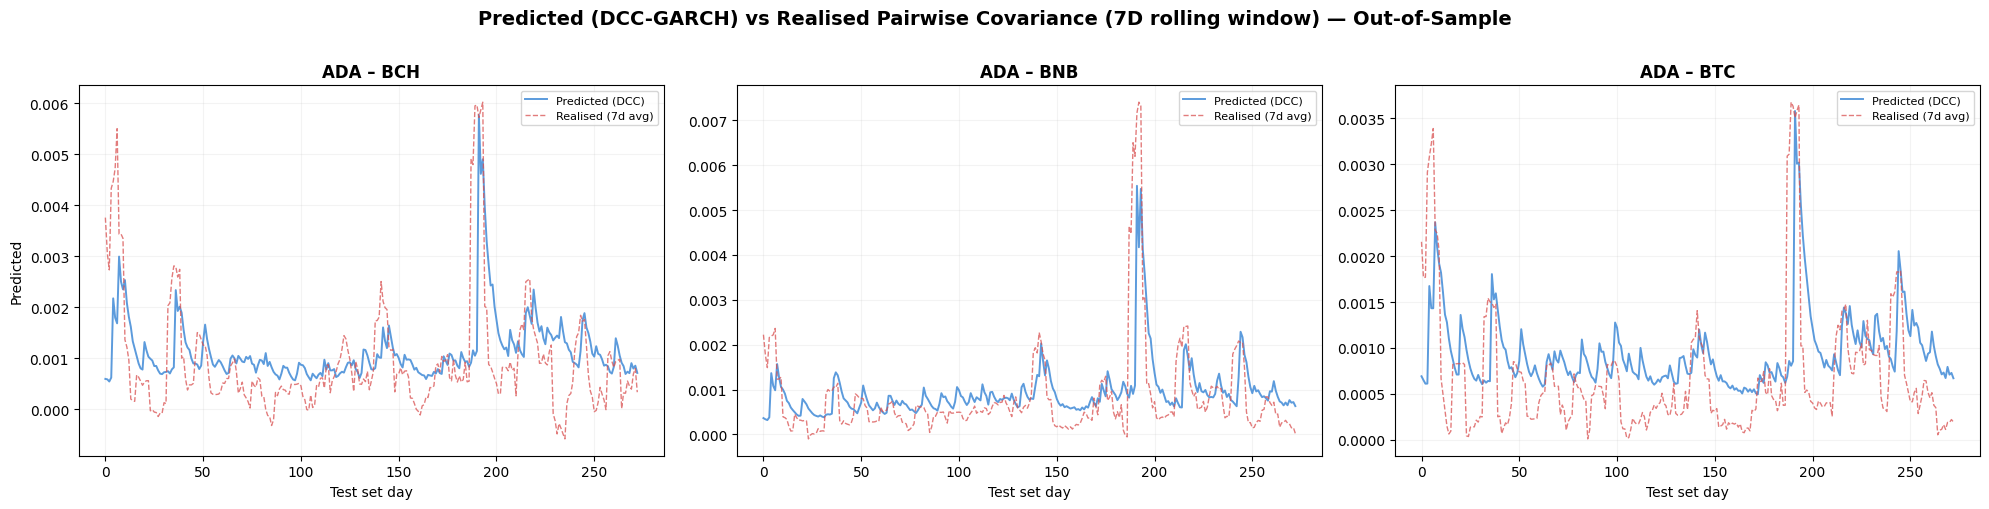

In [26]:
pair_indices = list(itertools.combinations(range(len(coins_to_use)), 2))[:3]

# Test returns for realised covariance proxy
test_returns_array = test_log_returns[coins_to_use].values  # shape (T, N)

# Smoothing window for realised covariance
SMOOTH_WINDOW = 7

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True)
axes = axes.flatten()

for idx, (i, j) in enumerate(pair_indices):
    ax = axes[idx]
    coin_i = coins_to_use[i].replace("USDT", "")
    coin_j = coins_to_use[j].replace("USDT", "")

    # Predicted: DCC covariance entry (i, j) at each time step
    predicted = test_H_all[:, i, j]

    # Realised: outer product proxy r_i * r_j
    realized_raw = test_returns_array[:, i] * test_returns_array[:, j]

    # Smooth realised with rolling mean
    realized_smooth = pd.Series(realized_raw).rolling(
        window=SMOOTH_WINDOW, center=True, min_periods=1
    ).mean().values

    # Plot
    ax.plot(predicted, color="#4a90d9", linewidth=1.4, label="Predicted (DCC)", alpha=0.9)
    ax.plot(realized_smooth, color="#d95050", linewidth=1.0, linestyle="--",
            label=f"Realised ({SMOOTH_WINDOW}d avg)", alpha=0.75)
    ax.set_title(f"{coin_i} – {coin_j}", fontsize=12, fontweight="bold")
    # ax.set_ylabel("Covariance")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.15)

# axes[-4].set_xlabel("Test set day")
axes[-3].set_xlabel("Test set day")
axes[-2].set_xlabel("Test set day")
axes[-1].set_xlabel("Test set day")
axes[0].set_ylabel("Predicted")

fig.suptitle(
    "Predicted (DCC-GARCH) vs Realised Pairwise Covariance (7D rolling window) — Out-of-Sample",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

### Saving to npy file

In [28]:
full_H_all = np.concatenate([H_all, test_H_all], axis=0)
print(f"Full covariance matrices: {full_H_all.shape}")
np.save("13 DCC GARCH results/dcc_garch_daily_covariance_matrices.npy", full_H_all)

print(f"Test covariance matrices: {test_H_all.shape}")
np.save("13 DCC GARCH results/dcc_garch_daily_covariance_matrices_test.npy", test_H_all)

Full covariance matrices: (1369, 8, 8)
Test covariance matrices: (273, 8, 8)
